<a href="https://www.kaggle.com/code/nicapotato/universal-sentence-encoder-clustering-poc?scriptVersionId=320617495" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Universal Sentence Encoder Clustering POC
_by Nick Brooks, Feb 2020_

**Resources:** <br>
- [Word Embeddings Guide Tensorflow](https://www.tensorflow.org/tutorials/text/word_embeddings)
- [Universal Sentence Encoder Tensorflow Hub](https://tfhub.dev/google/universal-sentence-encoder-large/5)


**Similar Notebooks:** <br>
- [Universal Sentence Encoder Semantic Similarity](https://www.kaggle.com/nicapotato/universal-sentence-encoder-semantic-similarity/)
- [Clasify Tweets with BERT](https://www.kaggle.com/nicapotato/bert-oof-with-dense-features)

### Table of Content
1. Universal Sentence Encoder Clustering
1. Universal Sentence Encoder Fine-Tuning

In [1]:
import pandas as pd
import numpy as np

import tensorflow_hub as hub
from sklearn.cluster import KMeans
import time
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import KFold

pd.options.display.max_colwidth = 500
print("Tensorflow Hub Version: ", hub.__version__)

SEED = 42

notebookstart = time.time()
module_url = 'https://tfhub.dev/google/universal-sentence-encoder-large/4'
USE_embed = hub.KerasLayer(module_url, trainable=False, name='USE_embedding')

Tensorflow Hub Version:  0.7.0


#### Prepare Toy Data

In [2]:
toy_data = [
    ["My flight got cancelled and I didn't get a refund.", "travel"],
    ["The pilot said the delays were due to ice on the wings.", "travel"],
    ["The airport was closed due to a terrorist threat.", "travel"],
    ["The plane coudn't take off, so the airline booked us into the Marriott nearby.", "travel"],
    ["Room service was friendly and professional, I will definitely be back!", "hotel"],
    ["Hotel was having a huge function and I had no room to enjoy the facilities.", "hotel"],
    ["I was charged 10$ for a water in the mini fridge, ridiculous!!!", "hotel"],
    ["The soccer and basketball events were badly organised.", "activities"],
    ["I wish that they would offer surfing in the itinerary, the weather was perfect for it.", "activities"],
    ["I swim at 8 AM every day to train for the competition", "activities"],
    ["Lets get a together an plan a giant ski trip in France", "activities"],
    ["Today is gonna be the day that we're gonna throw it back to you.", "other"],
    ["I wish the duty free stores had more liquor options", "travel"],
    ["There was no more room at the gate, so I was forced to stand up for 30 minutes", "travel"],
    ["The airport security held me up for a petty reason and wasted my time","travel"],
    ["I had a great experience at the Aspire Lounge, I really enjoyed the food", "travel"],
    ["I was once again unable to enter the lounge, I was turned down due to capacity","travel"],
    ["Flights prices during the holiday are way to high, this is outrageous.", "travel"],
    ["Prices on this website seem to change every 10 seconds, I don't like it.", "travel"],
    ["I had a hard time finding the lounge, I am thankful for the Priority Pass navigation system", "travel"],
    ["This hotel was very full over the weekend, I wish they had more space", "hotel"],
    ["I was able to check into my room in 5 minutes, super easy", "hotel"],
    ["This hotel was full of corporate types, they ruined my holiday.", "hotel"],
    ["I loved my UCPA ski holiday, the food was great, and I learned lots of snowboarding tricks", "activities"],
    ["Next time I go to the beach, I will definitely try to surf", "activities"]
]

df = pd.DataFrame(toy_data, columns = ['review','category'])
print(df.category.value_counts().to_dict())
print("")
display(df)

{'travel': 12, 'hotel': 6, 'activities': 6, 'other': 1}



,review,category
0,My flight got cancelled and I didn't get a refund.,travel
1,The pilot said the delays were due to ice on the wings.,travel
2,The airport was closed due to a terrorist threat.,travel
3,"The plane coudn't take off, so the airline booked us into the Marriott nearby.",travel
4,"Room service was friendly and professional, I will definitely be back!",hotel
5,Hotel was having a huge function and I had no room to enjoy the facilities.,hotel
6,"I was charged 10$ for a water in the mini fridge, ridiculous!!!",hotel
7,The soccer and basketball events were badly organised.,activities
8,"I wish that they would offer surfing in the itinerary, the weather was perfect for it.",activities
9,I swim at 8 AM every day to train for the competition,activities


#### Fit Universal Sentence Encoder and Fit Kmeans Algorithm

In [3]:
train, validation = train_test_split(df.values, test_size=0.40, random_state=23)
train = pd.DataFrame(train, columns = df.columns)
validation = pd.DataFrame(validation, columns = df.columns)

In [4]:
train_embeddings = USE_embed(train.review)['outputs'].numpy()

kmeans = KMeans(n_clusters=3, random_state=SEED).fit(train_embeddings)
train.loc[:,'Clusters'] = None
train.loc[:,'Clusters'] = kmeans.labels_

display(train.sort_values(by = 'category'))

,review,category,Clusters
4,"Next time I go to the beach, I will definitely try to surf",activities,1
6,"I loved my UCPA ski holiday, the food was great, and I learned lots of snowboarding tricks",activities,1
7,The soccer and basketball events were badly organised.,activities,2
11,I swim at 8 AM every day to train for the competition,activities,1
12,"I wish that they would offer surfing in the itinerary, the weather was perfect for it.",activities,1
0,Hotel was having a huge function and I had no room to enjoy the facilities.,hotel,0
10,"This hotel was full of corporate types, they ruined my holiday.",hotel,2
13,"I was charged 10$ for a water in the mini fridge, ridiculous!!!",hotel,1
5,Today is gonna be the day that we're gonna throw it back to you.,other,1
1,The airport was closed due to a terrorist threat.,travel,2


In [5]:
print("Homogeneity: %0.3f" % metrics.homogeneity_score(train.category, kmeans.labels_))
print("Completeness: %0.3f" % metrics.completeness_score(train.category, kmeans.labels_))
print("V-measure: %0.3f" % metrics.v_measure_score(train.category, kmeans.labels_))
print("Adjusted Rand-Index: %.3f"
      % metrics.adjusted_rand_score(train.category, kmeans.labels_))
print("Silhouette Coefficient: %0.3f"
      % metrics.silhouette_score(train_embeddings, train.category, sample_size=1000))

display(pd.crosstab(train['Clusters'], train['category']))

Homogeneity: 0.360
Completeness: 0.409
V-measure: 0.383
Adjusted Rand-Index: 0.223
Silhouette Coefficient: 0.013


category,activities,hotel,other,travel
Clusters,,,,
0,0,1,0,4
1,4,1,1,0
2,1,1,0,2


#### Predict on New cases..

In [6]:
def kmeans_predict(text_input, fitted_kmeans):
    tmp_embd = USE_embed([text_input])['outputs'].numpy()
    return fitted_kmeans.predict(tmp_embd)[0]

validation["Clusters"] = validation.review.apply(lambda t: kmeans_predict(text_input=t,fitted_kmeans=kmeans))
display(pd.crosstab(validation['Clusters'], validation['category']))

category,activities,hotel,travel
Clusters,,,
0,0,3,1
1,1,0,1
2,0,0,4


### Fine Tuning

In [7]:
import tensorflow as tf
import tensorflow_hub as hub
from keras import backend as K

from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout, concatenate, GlobalAveragePooling1D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD
from keras.utils import to_categorical
import itertools

import matplotlib.pyplot as plt

print("Tensorflow Version: ", tf.__version__)

Tensorflow Version:  2.1.0


Using TensorFlow backend.


In [8]:
df['labels'] = df['category'].map({"travel":0,"hotel":1,"activities":2})
class_names = ["trave","hotel","activities"]
train_data = df.loc[df.labels.notnull(),:].reset_index().copy()
train_data['labels'] = train_data['labels'].astype(int)
train_data['review'] = train_data['review'].astype(str)

categorical_labels = to_categorical(train_data['labels'].values, num_classes=None)
output_size = categorical_labels.shape[1]

print('Inpus Shape: {}, Output Shape: {}'.format(train_data['review'].shape, categorical_labels.shape))

Inpus Shape: (24,), Output Shape: (24, 3)


In [9]:
def build_model(embed, output_size=output_size):
    
    model = Sequential([
        Input(shape=[], dtype=tf.string),
        embed,
        Dense(output_size, activation='softmax')
    ])
    model.compile(Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

model = build_model(USE_embed)
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
USE_embedding (KerasLayer)   {'outputs': (None, 512)}  147354880 
_________________________________________________________________
dense (Dense)                (None, 3)                 1539      
Total params: 147,356,419
Trainable params: 1,539
Non-trainable params: 147,354,880
_________________________________________________________________


Train on 16 samples, validate on 8 samples
Epoch 1/40
16/16 [==============================] - 42s 3s/sample - loss: 1.1077 - accuracy: 0.3750 - val_loss: 1.0455 - val_accuracy: 0.8750
Epoch 2/40
16/16 [==============================] - 1s 55ms/sample - loss: 1.0905 - accuracy: 0.3750 - val_loss: 1.0411 - val_accuracy: 0.8750
Epoch 3/40
16/16 [==============================] - 1s 45ms/sample - loss: 1.0752 - accuracy: 0.5625 - val_loss: 1.0367 - val_accuracy: 0.8750
Epoch 4/40
16/16 [==============================] - 1s 45ms/sample - loss: 1.0608 - accuracy: 0.5625 - val_loss: 1.0317 - val_accuracy: 0.8750
Epoch 5/40
16/16 [==============================] - 1s 46ms/sample - loss: 1.0462 - accuracy: 0.7500 - val_loss: 1.0261 - val_accuracy: 0.8750
Epoch 6/40
16/16 [==============================] - 1s 45ms/sample - loss: 1.0322 - accuracy: 0.7500 - val_loss: 1.0210 - val_accuracy: 0.8750
Epoch 7/40
16/16 [==============================] - 1s 45ms/sample - loss: 1.0194 - accuracy: 0.8750

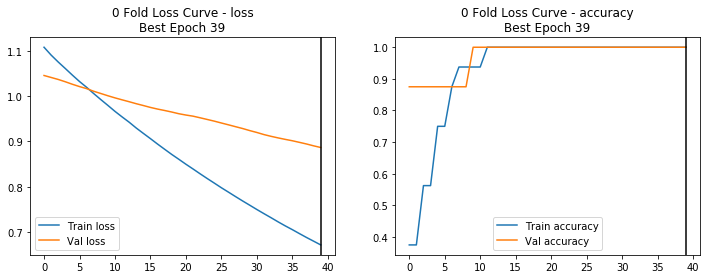

Train on 16 samples, validate on 8 samples
Epoch 1/40
16/16 [==============================] - 28s 2s/sample - loss: 1.0682 - accuracy: 0.6250 - val_loss: 1.0698 - val_accuracy: 0.5000
Epoch 2/40
16/16 [==============================] - 1s 54ms/sample - loss: 1.0514 - accuracy: 0.6250 - val_loss: 1.0642 - val_accuracy: 0.5000
Epoch 3/40
16/16 [==============================] - 1s 70ms/sample - loss: 1.0373 - accuracy: 0.7500 - val_loss: 1.0578 - val_accuracy: 0.5000
Epoch 4/40
16/16 [==============================] - 1s 47ms/sample - loss: 1.0221 - accuracy: 0.7500 - val_loss: 1.0518 - val_accuracy: 0.5000
Epoch 5/40
16/16 [==============================] - 1s 45ms/sample - loss: 1.0082 - accuracy: 0.7500 - val_loss: 1.0460 - val_accuracy: 0.5000
Epoch 6/40
16/16 [==============================] - 1s 46ms/sample - loss: 0.9946 - accuracy: 0.7500 - val_loss: 1.0404 - val_accuracy: 0.5000
Epoch 7/40
16/16 [==============================] - 1s 46ms/sample - loss: 0.9814 - accuracy: 0.7500

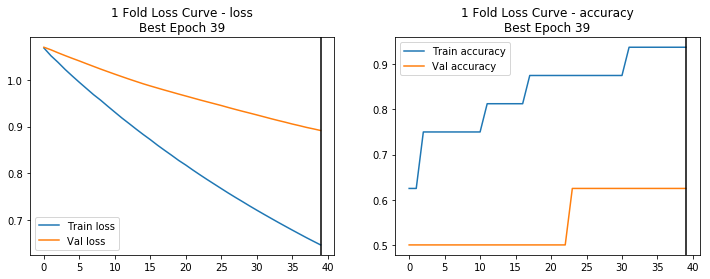

Train on 16 samples, validate on 8 samples
Epoch 1/40
16/16 [==============================] - 27s 2s/sample - loss: 1.1045 - accuracy: 0.3125 - val_loss: 1.0756 - val_accuracy: 0.5000
Epoch 2/40
16/16 [==============================] - 1s 55ms/sample - loss: 1.0841 - accuracy: 0.3125 - val_loss: 1.0742 - val_accuracy: 0.3750
Epoch 3/40
16/16 [==============================] - 1s 46ms/sample - loss: 1.0626 - accuracy: 0.5000 - val_loss: 1.0722 - val_accuracy: 0.3750
Epoch 4/40
16/16 [==============================] - 1s 45ms/sample - loss: 1.0436 - accuracy: 0.6875 - val_loss: 1.0699 - val_accuracy: 0.3750
Epoch 5/40
16/16 [==============================] - 1s 46ms/sample - loss: 1.0270 - accuracy: 0.8750 - val_loss: 1.0683 - val_accuracy: 0.6250
Epoch 6/40
16/16 [==============================] - 1s 47ms/sample - loss: 1.0092 - accuracy: 0.9375 - val_loss: 1.0668 - val_accuracy: 0.6250
Epoch 7/40
16/16 [==============================] - 1s 46ms/sample - loss: 0.9914 - accuracy: 0.9375

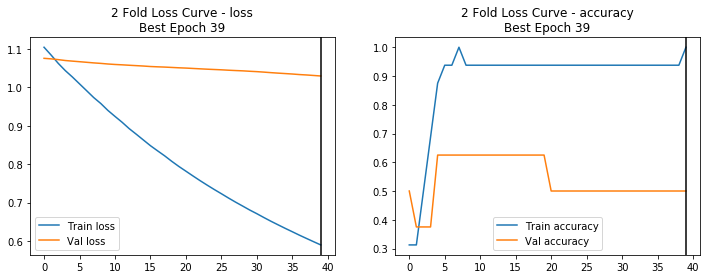

In [10]:
oof_preds = np.zeros([train_data.shape[0], output_size])

n_splits = 3
folds = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
plot_metrics = ['loss','accuracy']

fold_hist = {}
for i, (trn_idx, val_idx) in enumerate(folds.split(train_data)):
    modelstart = time.time()
    model = build_model(USE_embed)
    
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0.0001, patience=4, verbose=1,
                                 mode='min', baseline=None, restore_best_weights=True)
    
    history = model.fit(
        train_data.review[trn_idx].values,
        categorical_labels[trn_idx],
        validation_data=(
            train_data.review[val_idx].values,
            categorical_labels[val_idx]),
        epochs=40,
        batch_size=6,
        callbacks = [es],
        verbose=1)
    
    best_index = np.argmin(history.history['val_loss'])
    fold_hist[i] = history
    
    oof_preds[val_idx] = model.predict(train_data.review[val_idx].values)
    
    f, ax = plt.subplots(1,len(plot_metrics),figsize = [12,4])
    for p_i,metric in enumerate(plot_metrics):
        ax[p_i].plot(history.history[metric], label='Train ' + metric)
        ax[p_i].plot(history.history['val_' + metric], label='Val ' + metric)
        ax[p_i].set_title("{} Fold Loss Curve - {}\nBest Epoch {}".format(i, metric, best_index))
        ax[p_i].legend()
        ax[p_i].axvline(x=best_index, c='black')
    plt.show()

In [11]:
# Confusion matrix 
def plot_confusion_matrix(cm, classes,
                          title = 'Confusion matrix"',
                          cmap = plt.cm.Blues) :
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation = 0)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])) :
        plt.text(j, i, cm[i, j],
                 horizontalalignment = 'center',
                 color = 'white' if cm[i, j] > thresh else 'black')
 
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

Accuracy: 0.71
Confusion Matrix


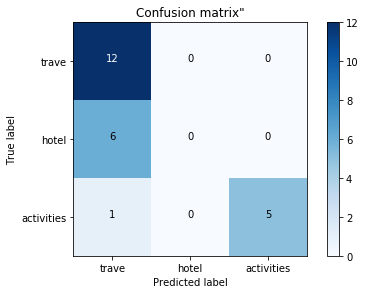

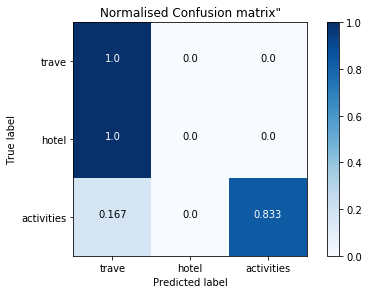

In [12]:
preds = oof_preds.argmax(axis = 1)
print("Accuracy: {:.2f}".format(metrics.accuracy_score(train_data['labels'], preds)))
print("Confusion Matrix")
plot_confusion_matrix(metrics.confusion_matrix(train_data['labels'], preds),
                          class_names,
                          title = 'Confusion matrix"',
                          cmap = plt.cm.Blues)
cm = metrics.confusion_matrix(train_data['labels'], preds, normalize = 'true').round(3)
plot_confusion_matrix(cm,
                          class_names,
                          title = 'Normalised Confusion matrix"',
                          cmap = plt.cm.Blues)

In [13]:
print("Notebook Runtime: %0.2f Minutes"%((time.time() - notebookstart)/60))

Notebook Runtime: 4.91 Minutes
